# Product Recognition with NNS
### A project by Francesco Cenerini, Enrico Strangio e Niccolò Leoncini

## Introduzione
L'obiettivo di questo progetto è implementare un sistema di riconoscimento di prodotti alimentari a partire da immagini acquisite con smartphone in contesti reali (supermercati) utilizzando la ricerca tramite *nearest-neighbour*. Il sistema deve, per ogni immagine di query, determinare la classe di appartenenza confrontando il suo embedding con quelli di un insieme di immagini prototipo.

Il sistema si articola in due fasi principali:

1. **Enrollment Phase**: Le immagini prototipo vengono passate attraverso un backbone CNN pre-addestrato per estrarne gli embedding. Questi vengono raccolti in una gallery. Testiamo due strategie di gallery:
   - **Gallery ALL**: tutti gli embedding dei prototipi disponibili;
   - **Gallery MEAN**: un unico embedding medio per classe.

2. **Inference Phase**: Ogni immagine di query viene processata dallo stesso backbone e confrontata con la gallery tramite due metriche di distanza:
   - **Cosine Similarity**: misura dell'angolo tra i vettori;
   - **Distanza di Mahalanobis** (con riduzione PCA): tiene conto della correlazione tra le feature.

Per analizzare l'impatto dell'architettura sulle performance, confrontiamo quattro backbone pre-addestrati su ImageNet:

| Backbone | Architettura | Dim. Embedding | Training |
|----------|-------------|----------------|----------|
| ResNet-18 | CNN residuale | 512-D | ImageNet supervised |
| ResNet-50 | CNN residuale | 2048-D | ImageNet supervised |
| DINOv2-Small | Vision Transformer | 384-D | Self-supervised (DINO v2) |
| DINOv3-Small | Vision Transformer | 384-D | Self-supervised (DINO v3) |

## Setup dell'ambiente e dipendenze

Come prima cosa, eseguiamo il download del dataset da GitHub ed installiamo i pacchetti necessari delle varie librerie che utilizzeremo all'interno del progetto.

In [ ]:
# Installazione delle dipendenze
# keras-hub: libreria Keras per backbone pre-addestrati (ResNet18, ResNet50, DINOv2, DINOv3)
# scipy: utilizzato per la distanza di Mahalanobis tramite cdist
# scikit-learn: utilizzato per la PCA prima del calcolo di Mahalanobis
!pip install -q keras-hub scipy scikit-learn tensorflow
!git clone https://github.com/enristra/product-recognition

fatal: destination path 'product-recognition' already exists and is not an empty directory.


In [ ]:
import os
import gc
import numpy as np
import tensorflow as tf
import keras_hub
from keras_hub import models as hub_models
from tensorflow.keras.backend import clear_session
from tensorflow.keras.utils import set_random_seed
from keras import Input, Model
from keras.layers import GlobalAveragePooling2D
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

## Configurazione

La fase di configurazione prevede di raggruppare tutti gli iperparametri in un unico punto per facilitarne la modifica. Ogni scelta è stata commentata con la sua motivazione.

In [ ]:
# Dimensioni di input delle immagini.
# 224×224 è la dimensione standard per ResNet (e per DINOv2/DINOv3 in questa configurazione,
# che internamente interpola i patch embedding da 518 -> 224).
IMG_HEIGHT = 224
IMG_WIDTH  = 224
IMG_SIZE   = (IMG_HEIGHT, IMG_WIDTH)
CHANNELS   = 3 # immagini RGB

# Batch size per l'estrazione degli embedding.
# 32 è un buon compromesso tra velocità e utilizzo di memoria GPU/CPU.
BATCH_SIZE = 32

# Path assoluto al dataset su Drive
BASE_DIR  = "/content/product-recognition/product_recognition_with_NNS/nn_search_dataset"
# Percorsi del dataset
PROTO_DIR  = f"{BASE_DIR}/prototypes"  # immagini prototipo (gallery)
QUERY_DIR  = f"{BASE_DIR}/queries"     # immagini di query

# Impostazione del seed per la riproducibilità degli esperimenti
# (utilizzato dalla PCA e dalla generazione di numeri casuali)
SEED = 42
np.random.seed(SEED)
set_random_seed(SEED)

Al fine di evitare accumuli di memoria tra l'esecuzione di un backbone e il successivo, è stata implementata la funzione ausiliaria `empty_cache()`. Essa invoca `clear_session()` di Keras che distrugge il grafo computazionale corrente e libera i pesi dal dispositivo e il garbage collector di Python, così da recuperare la memoria RAM/GPU prima di caricare il modello successivo.

In [ ]:
def empty_cache():
    clear_session()
    gc.collect()

## Caricamento del dataset

Il dataset è strutturato con due sottocartelle principali `prototypes` e `queries`, ognuna con una sottodirectory per ogni classe. Usiamo la funzione  `image_dataset_from_directory` di Keras, che inferisce automaticamente le label numeriche dall'ordine alfabetico delle sottocartelle e restituisce un `tf.data.Dataset` già batched.

### Preprocessing
Applichiamo la normalizzazione standard ImageNet per canale (media `[0.485, 0.456, 0.406]`, deviazione standard `[0.229, 0.224, 0.225]`), in linea con il preprocessing usato durante il pre-addestramento di tutti i backbone considerati.

In [ ]:
def preprocess(image, label):
    """
    Normalizzazione ImageNet applicata a ogni immagine del dataset.

    Le immagini grezze hanno valori in [0, 255] (uint8).
    Convertiamo in float32 e applichiamo:
        image_norm = (image - mean * 255) / (std * 255)
    dove mean=[0.485, 0.456, 0.406] e std=[0.229, 0.224, 0.225] sono
    le statistiche calcolate sul dataset ImageNet (canali RGB).

    Questa normalizzazione è FONDAMENTALE: tutti i backbone sono stati
    addestrati con questo preprocessing, quindi è necessario applicarlo
    anche in fase di inferenza per rispettare la distribuzione attesa.
    """
    image = tf.cast(image, tf.float32)
    mean  = tf.constant([0.485, 0.456, 0.406]) * 255.0
    std   = tf.constant([0.229, 0.224, 0.225]) * 255.0
    image = (image - mean) / std
    return image, label


def get_proto_dataset(shuffle=False):
    """
    Carica il dataset dei prototipi (gallery) da PROTO_DIR.

    Parametri:
        shuffle (bool): se True, mescola i dati. Impostato False per
                        garantire corrispondenza stabile tra embedding e label.
    """
    dataset = tf.keras.utils.image_dataset_from_directory(
        PROTO_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        label_mode="int",  # label intere
    )
    class_names = dataset.class_names  # salviamo prima di map() che li cancellerebbe
    dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)  # overlap I/O e computazione
    return dataset, class_names


def get_query_dataset(shuffle=False):
    """
    Carica il dataset delle query da QUERY_DIR.
    Stessa struttura e preprocessing dei prototipi.
    """
    dataset = tf.keras.utils.image_dataset_from_directory(
        QUERY_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        label_mode="int",
    )
    class_names = dataset.class_names
    dataset = dataset.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset, class_names


# Test del caricamento: verifica struttura e nomi delle classi
test_dataset, class_names = get_proto_dataset(shuffle=False)
print(f"Classi trovate ({len(class_names)}):")
for i, name in enumerate(class_names):
    print(f"  [{i:2d}] {name}")

Found 407 files belonging to 14 classes.
Classi trovate (14):
  [ 0] Asparagus
  [ 1] Aubergine
  [ 2] Beet
  [ 3] Cabbage
  [ 4] Carrots
  [ 5] Cucumber
  [ 6] Ginger
  [ 7] Leek
  [ 8] Mushroom
  [ 9] Onion
  [10] Pepper
  [11] Potato
  [12] Tomato
  [13] Zucchini


## Definizione dei backbone

Per ciascun backbone utilizziamo i pesi pre-addestrati forniti da **keras-hub** e rimuoviamo la testa classificatoria per ottenere una rappresentazione compatta dell'immagine:

- **ResNet-18 / ResNet-50**: utilizziamo versioni pre-addestrate in modo supervisionato sul dataset ImageNet-1K. La backbone CNN produce una feature map spaziale $(H \times W \times C)$. Applichiamo `GlobalAveragePooling2D` per collassare le dimensioni spaziali e ottenere un vettore di embedding `(C,)`.
- **DINOv2-small / DINOv3-small**: utilizziamo backbone Vision Transformer pre-addestrate con apprendimento self-supervised secondo gli approcci DINOv2 e DINOv3. La backbone produce una sequenza di token `(N_patches + 1, D)`. Estraiamo il **CLS token** (indice 0), che per costruzione aggrega l'informazione globale dell'immagine.

In tutti i casi, i pesi sono **congelati** (`trainable=False`): i backbone vengono utilizzati esclusivamente come feature extractor senza alcun aggiornamento dei parametri durante l'addestramento.

In [ ]:
def resnet18_feature_extractor():
    """
    ResNet-18 pre-addestrata su ImageNet come feature extractor.
    """
    backbone = hub_models.ResNetBackbone.from_preset("resnet_18_imagenet")
    backbone.trainable = False  # pesi congelati: nessun aggiornamento gradiente

    inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    x = backbone(inputs)            # feature map (7×7×512)
    x = GlobalAveragePooling2D()(x) # → vettore 512-D
    return Model(inputs, x, name="resnet18_feature_extractor")


def resnet50_feature_extractor():
    """
    ResNet-50 pre-addestrata su ImageNet come feature extractor.
    """
    backbone = hub_models.ResNetBackbone.from_preset("resnet_50_imagenet")
    backbone.trainable = False

    inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    x = backbone(inputs)            # feature map (7×7×2048)
    x = GlobalAveragePooling2D()(x) # → vettore 2048-D
    return Model(inputs, x, name="resnet50_feature_extractor")


def dinoV2small_feature_extractor():
    """
    DINOv2-Small (Vision Transformer) pre-addestrato con DINO v2
    """
    backbone = hub_models.DINOV2Backbone.from_preset(
        "dinov2_small",
        image_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS) # riduzione della risoluzione delle immagini da 518x518 a 224x224
    )
    backbone.trainable = False

    inputs  = Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    outputs = backbone({"images": inputs})  # sequenza token (batch, N_tokens, 384)
    x = outputs[:, 0, :]                   # CLS token → (batch, 384)
    return Model(inputs, x, name="dinoV2small_feature_extractor")


def dinoV3small_feature_extractor():
    """
    DINOv3-Small pre-addestrato con DINO v3

    La chiave di input cambia rispetto a DINOv2: usa 'pixel_values' invece di 'images'.
    Anche qui estraiamo il CLS token (indice 0).
    """
    backbone = hub_models.DINOV3Backbone.from_preset("dinov3_vit_small_lvd1689m")
    backbone.trainable = False

    inputs  = Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    outputs = backbone({"pixel_values": inputs})  # chiave diversa da DINOv2!
    x = outputs[:, 0, :]                          # CLS token → (batch, 384)
    return Model(inputs, x, name="dinoV3small_feature_extractor")


# Dizionario backbone per iterazione
BACKBONES = {
    "ResNet-18"   : resnet18_feature_extractor,
    "ResNet-50"   : resnet50_feature_extractor,
    "DINOv2-Small": dinoV2small_feature_extractor,
    "DINOv3-Small": dinoV3small_feature_extractor,
}

print("Backbone disponibili:", list(BACKBONES.keys()))

Backbone disponibili: ['ResNet-18', 'ResNet-50', 'DINOv2-Small', 'DINOv3-Small']


## Funzioni di estrazione degli embedding

La funzione `extract_embeddings` itera sul dataset batched e concatena gli output del modello, restituendo una matrice $(N \times D)$ dove $N$ è il numero di immagini e $D$ la dimensione dell'embedding.

In [ ]:
def extract_embeddings(model, dataset):
    """
    Passa l'intero dataset attraverso il modello e raccoglie gli embedding.

    Il parametro training=False disabilita layer stochastici come Dropout
    e BatchNorm in modalità di stima (usa media/varianza del training),
    garantendo output deterministici durante l'inferenza.

    Ritorna:
        embeddings : np.ndarray (N, D) — N immagini × D dimensioni embedding
        labels     : np.ndarray (N,)   — label intere corrispondenti
    """
    all_embeddings, all_labels = [], []
    for images, labels in dataset:
        embs = model(images, training=False)  # forward pass senza aggiornamenti
        all_embeddings.append(embs.numpy())
        all_labels.append(labels.numpy())
    # np.concatenate unisce i batch in un unico array
    return np.concatenate(all_embeddings, axis=0), np.concatenate(all_labels, axis=0)

## Metriche utilizzate

### Cosine Similarity

La **cosine similarity** misura l'angolo tra due vettori nello spazio degli embedding. È robusta alle variazioni di scala (es. illuminazione) ed è la metrica standard per il retrieval su rappresentazioni neurali, dato che mette a confronto la direzione dei vettori piuttosto che la loro magnitudine.

### Distanza di Mahalanobis con PCA

La **distanza di Mahalanobis** tiene conto dell'intera struttura di covarianza dello spazio delle feature, normalizzando le distanze in base alla variabilità di ciascuna direzione e alle correlazioni tra le dimensioni.

Durante lo sviluppo di questa soluzione abbiamo riscontrato il seguente problema: stimare la matrice di covarianza inversa in spazi ad alta dimensione (512-D, 2048-D) richiede molti più campioni del numero di classi disponibili, portando a stime instabili o singolari. La soluzione addottata è stata quella di calcolare prima la distanza, riducendo la dimensionalità con PCA a `n_components=50`, in modo da ottenere una matrice di covarianza $(50 \times 50)$ ben condizionata e invertibile.

In [ ]:
def cosine_similarity_matrix(query_embs, gallery_embs):
    """
    Calcola la matrice di cosine similarity tra query e gallery.

    Implementazione: normalizzazione L2 + prodotto matriciale.
    Equivalente a calcolare il coseno dell'angolo tra ogni coppia (query, gallery).

    Usiamo tf.linalg.matmul per sfruttare la GPU se disponibile,
    rendendo il calcolo più veloce su dataset grandi.

    Ritorna:
        sim_matrix : np.ndarray (N_q, N_g) — valori in [-1, 1]
    """
    query_embs   = tf.nn.l2_normalize(query_embs,   axis=1)  # normalizzazione L2 per riga
    gallery_embs = tf.nn.l2_normalize(gallery_embs, axis=1)
    # Prodotto matriciale: (N_q, D) x (D, N_g) → (N_q, N_g)
    return tf.linalg.matmul(query_embs, gallery_embs, transpose_b=True).numpy()


def nearest_neighbour_predict(sim_matrix, gallery_labels):
    """
    Predice la classe di ogni query come quella del prototipo più simile (1-NN).

    Strategia: per ogni riga (query), prende l'indice del massimo nella
    matrice di similarità e recupera la label corrispondente dalla gallery.

    Ritorna:
        pred_labels : np.ndarray (N_q,)
    """
    nn_indices = np.argmax(sim_matrix, axis=1)  # indice del prototipo più vicino
    return gallery_labels[nn_indices]


def compute_inv_cov_pca(embs, labels, n_components=50):
    """
    Stima la matrice di covarianza intra-classe inversa nello spazio PCA ridotto.

    Procedura:
        1. PCA fit sugli embedding della gallery/training set
        2. Centratura per classe nello spazio ridotto (rimuove la media intra-classe)
        3. Stima della covarianza (50×50) con regolarizzazione (+ λ·I, λ=1e-5)
        4. Inversione: Σ^{-1} stabile grazie alla regolarizzazione

    Ritorna:
        pca     : sklearn.decomposition.PCA — trasformazione da applicare alle query
        inv_cov : np.ndarray (n_components, n_components) — matrice di covarianza inversa
    """
    unique_labels = np.unique(labels)
    dof = len(embs) - len(unique_labels)  # gradi di libertà effettivi

    if n_components >= dof:
        # Sicurezza: evitiamo overfitting riducendo ulteriormente n_components
        print(f"Attenzione: n_components={n_components} >= DoF={dof}. Ridotto a {dof // 4}.")
        n_components = max(1, dof // 4)

    # 1. PCA: proietta gli embedding in uno spazio a bassa dimensione
    #    random_state=42 garantisce riproducibilità del risultato
    pca = PCA(n_components=n_components, random_state=SEED)
    embs_pca = pca.fit_transform(embs)  # (N, D) → (N, n_components)

    # 2. Centratura per classe: sottrae la media di ogni classe dai suoi campioni
    #    Questo rende la stima di covarianza indipendente dalla posizione delle classi
    centered = np.vstack([
        embs_pca[labels == c] - embs_pca[labels == c].mean(axis=0)
        for c in unique_labels
    ])

    # 3. Stima covarianza (n_components × n_components)
    cov = np.cov(centered, rowvar=False)

    # 4. Regolarizzazione (Tikhonov / ridge): + λ·I per garantire invertibilità
    #    λ=1e-5 è trascurabile rispetto ai valori tipici della covarianza,
    #    ma impedisce la singolarità numerica
    inv_cov = np.linalg.inv(cov + np.eye(n_components) * 1e-5)
    return pca, inv_cov


def mahalanobis_distance(query_embs, proto_embs, proto_labels, pca, inv_cov):
    """
    Classifica ogni query con 1-NN usando la distanza di Mahalanobis nello spazio PCA.

    Ritorna:
        pred_labels : np.ndarray (N_q,)
    """
    # Proiettiamo query e prototipi nello stesso spazio PCA
    # IMPORTANTE: usiamo transform (non fit_transform) per le query,
    # applicando la stessa trasformazione stimata sui prototipi
    query_embs = pca.transform(query_embs)
    proto_embs = pca.transform(proto_embs)

    # cdist calcola la matrice delle distanze (N_q, N_g) con metrica Mahalanobis
    # VI=inv_cov passa la matrice di covarianza inversa
    distances = cdist(query_embs, proto_embs, metric='mahalanobis', VI=inv_cov)
    return proto_labels[np.argmin(distances, axis=1)]  # 1-NN: indice del minimo

## Pipeline: Enrollment e Inference

La pipeline è strutturata in due fasi distinte: una prima fase di **enrollment**, in cui si costruisce la gallery a partire dagli embedding dei prototipi, e una seconda fase di **inference**, in cui gli embedding delle query vengono confrontati con quelli della gallery tramite le due metriche di distanza considerate (cosine similarity e Mahalanobis).

In [ ]:
def enrollment_phase(model, n_components=50):
    """
    ENROLLMENT PHASE: costruisce la gallery degli embedding dai prototipi.

    Testiamo due strategie di gallery:
    - Gallery ALL  : mantiene tutti gli embedding di ogni immagine prototipo.
                     Pro: più informazione per classe.
                     Contro: matching più lento (più confronti per query).
    - Gallery MEAN : calcola l'embedding medio per classe (un solo vettore/classe).
                     Pro: molto compatta, matching istantaneo.
                     Contro: possibile perdita di informazione intra-classe.

    La PCA e la matrice di covarianza inversa vengono stimate sugli embedding
    RAW di tutti i prototipi (gallery ALL), che offre più campioni per una
    stima statistica più robusta rispetto ai soli embedding medi.

    Ritorna:
        gallery_all  : (embs, labels) — tutti i prototipi
        gallery_mean : (mean_embs, unique_labels) — media per classe
        class_names  : lista nomi classi
        pca          : trasformazione PCA
        inv_cov      : matrice covarianza inversa
    """
    print("\n=== ENROLLMENT PHASE ===")
    proto_dataset, class_names = get_proto_dataset(shuffle=False)

    # Estrazione embedding per tutti i prototipi
    embs, labels = extract_embeddings(model, proto_dataset)
    unique_labels = np.unique(labels)

    # PCA + inv_cov calcolati sugli embedding RAW dei prototipi
    pca, inv_cov = compute_inv_cov_pca(embs, labels, n_components)

    # Gallery ALL: tutti i prototipi disponibili
    gallery_all  = (embs, labels)

    # Gallery MEAN: un embedding medio per classe (centroide della classe)
    mean_embs    = np.stack([embs[labels == c].mean(axis=0) for c in unique_labels])
    gallery_mean = (mean_embs, unique_labels)

    print(f"  Classi trovate ({len(class_names)}): {class_names}")
    print(f"  Gallery (all):  {embs.shape[0]} prototipi, dim embedding = {embs.shape[1]}")
    print(f"  Gallery (mean): {len(unique_labels)} prototipi (1 per classe), dim = {mean_embs.shape[1]}")
    return gallery_all, gallery_mean, class_names, pca, inv_cov


def inference_phase(model, gallery_all, gallery_mean, pca, inv_cov):
    """
    INFERENCE PHASE: classifica le query confrontandole con la gallery.

    Testiamo 4 combinazioni (2 gallery × 2 metriche):
    - all  | cosine      : gallery completa, cosine similarity
    - all  | mahalanobis : gallery completa, distanza di Mahalanobis (PCA)
    - mean | cosine      : gallery media, cosine similarity
    - mean | mahalanobis : gallery media, distanza di Mahalanobis (PCA)

    Ritorna:
        true_labels : np.ndarray (N_q,)
        pred_labels : dict {nome_metodo: np.ndarray (N_q,)}
    """
    print("\n=== INFERENCE PHASE ===")
    query_dataset, _ = get_query_dataset(shuffle=False)
    query_embs, true_labels = extract_embeddings(model, query_dataset)
    print(f"  Query set: {query_embs.shape[0]} immagini")

    pred_labels = {
        "all  | cosine"      : nearest_neighbour_predict(
                                   cosine_similarity_matrix(query_embs, gallery_all[0]),
                                   gallery_all[1]),
        "all  | mahalanobis" : mahalanobis_distance(
                                   query_embs, gallery_all[0], gallery_all[1], pca, inv_cov),
        "mean | cosine"      : nearest_neighbour_predict(
                                   cosine_similarity_matrix(query_embs, gallery_mean[0]),
                                   gallery_mean[1]),
        "mean | mahalanobis" : mahalanobis_distance(
                                   query_embs, gallery_mean[0], gallery_mean[1], pca, inv_cov),
    }
    return true_labels, pred_labels

## Funzioni di visualizzazione dei risultati
La funzione ausiliaria `print_results_table` produce una tabella riepilogativa che mostra, per ciascuna combinazione di gallery e metrica di distanza, l'accuracy globale e l'accuracy per ciascuna delle 14 classi. Questo formato consente di identificare rapidamente sia le configurazioni più performanti in termini assoluti, sia le classi che risultano più problematiche per un dato backbone.

In [ ]:
def print_results_table(true_labels, pred_labels, class_names):
    """
    Stampa una tabella con accuracy globale e per classe
    per ogni combinazione gallery/metrica.
    """
    print("\n=== RISULTATI ===")
    methods = list(pred_labels.keys())
    total   = len(true_labels)
    col_w   = 22

    # Intestazione colonne
    print(f"\n  {'Classe':<27}", end="")
    for m in methods:
        print(f"{m:^{col_w}}", end="")
    print()
    print("  " + "-" * (27 + col_w * len(methods)))

    # Accuracy globale
    print(f"  {'OVERALL':<27}", end="")
    for m in methods:
        acc = np.sum(true_labels == pred_labels[m]) / total * 100
        print(f"{acc:^{col_w}.2f}", end="")
    print()
    print("  " + "-" * (27 + col_w * len(methods)))

    # Accuracy per classe
    for i, name in enumerate(class_names):
        mask = (true_labels == i)
        if mask.sum() == 0:
            continue
        print(f"  [{i:2d}] {name:<23}", end="")
        for m in methods:
            cls_acc = np.mean(pred_labels[m][mask] == i) * 100
            print(f"{cls_acc:^{col_w}.2f}", end="")
        print()

## Esecuzione completa della pipeline

Di seguito viene eseguita la pipeline completa per ciascuno dei quattro backbone selezionati. Per ogni backbone, la procedura comprende: la costruzione del feature extractor a partire dai pesi pre-addestrati, la fase di enrollment con il calcolo delle gallery e della matrice di covarianza inversa, e la fase di inferenza con le quattro combinazioni gallery per metrica.

In [ ]:
# Numero di componenti PCA per la distanza di Mahalanobis.
# 50 è un buon compromesso: abbastanza per catturare la varianza discriminativa,
# abbastanza piccolo da garantire una stima stabile della covarianza.
PCA_COMPONENTS = 50

# Dizionario per raccogliere i risultati di tutti i backbone (per il confronto finale)
all_results = {}  # {backbone_name: {"true": ..., "pred": ..., "class_names": ...}}

for backbone_name, backbone_fn in BACKBONES.items():
    print(f"\n{'#'*70}")
    print(f"  BACKBONE: {backbone_name}")
    print(f"{'#'*70}")

    # 1. Costruzione del feature extractor con pesi pre-addestrati
    model = backbone_fn()
    model.summary(line_length=70)

    # 2. Enrollment: costruisce la gallery degli embedding dai prototipi
    gallery_all, gallery_mean, class_names, pca, inv_cov = enrollment_phase(
        model, n_components=PCA_COMPONENTS
    )

    # 3. Inference: classifica le query con le 4 combinazioni gallery/metrica
    true_labels, pred_labels = inference_phase(
        model, gallery_all, gallery_mean, pca, inv_cov
    )

    # 4. Stampa risultati
    print_results_table(true_labels, pred_labels, class_names)

    # 5. Salva i risultati per il confronto finale
    all_results[backbone_name] = {
        "true"       : true_labels,
        "pred"       : pred_labels,
        "class_names": class_names,
    }

    # Libera la memoria del modello corrente prima di caricare il successivo
    empty_cache()
    print(f"Esecuzione {backbone_name} completata.")


######################################################################
  BACKBONE: ResNet-18
######################################################################


100%|██████████| 836/836 [00:00<00:00, 1.20MB/s]


100%|██████████| 42.8M/42.8M [00:01<00:00, 28.7MB/s]


Model: "resnet18_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)   │ (None, 224, 224, 3)   │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ res_net_backbone             │ (None, 7, 7, 512)     │  11,186,112 │
│ (ResNetBackbone)             │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ global_average_pooling2d     │ (None, 512)           │           0 │
│ (GlobalAveragePooling2D)     │                       │             │
└──────────────────────────────┴───────────────────────┴─────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ input_layer (InputLayer)     │ (None, 224, 224, 3)   │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dinov3_backbone              │ (None, 201, 384)      │  21,596,544 │
│ (DINOV3Backbone)             │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ get_item (GetItem)           │ (None, 384)           │           0 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 21,596,544 (82.38 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,596,544 (82.38 MB)


=== ENROLLMENT PHASE ===
Found 407 files belonging to 14 classes.
  Classi trovate (14): ['Asparagus', 'Aubergine', 'Beet', 'Cabbage', 'Carrots', 'Cucumber', 'Ginger', 'Leek', 'Mushroom', 'Onion', 'Pepper', 'Potato', 'Tomato', 'Zucchini']
  Gallery (all):  407 prototipi, dim embedding = 384
  Gallery (mean): 14 prototipi (1 per classe), dim = 384

=== INFERENCE PHASE ===
Found 85 files belonging to 14 classes.
  Query set: 85 immagini

=== RISULTATI ===

  Classe                         all  | cosine       all  | mahalanobis      mean | cosine       mean | mahalanobis  
  -------------------------------------------------------------------------------------------------------------------
  OVERALL                            85.88                 89.41                 90.59                 90.59         
  -------------------------------------------------------------------------------------------------------------------
  [ 0] Asparagus                      60.00                 60.00   

## Confronto dei risultati tra backbone

In questa sezione vengono messe a confronto le performance dei quattro backbone considerati lungo tre dimensioni di analisi:

1. **Accuracy globale** per ogni combinazione backbone × gallery × metrica utilizzata;
2. **Miglior configurazione per backbone** (accuracy per classe visualizzata in heatmap);
3. **Analisi dell'impatto delle scelte architetturali e di training**.

La tabella riepilogativa permette di confrontare direttamente le 16 configurazioni valutate (4 backbone × 2 gallery × 2 metriche), evidenziando come ciascuna variabile come strategia di gallery e metrica di distanza, contribuisca alle performance complessive del sistema.

L'heatmap per classe, invece, è costruita selezionando, per ciascun backbone, la configurazione con la miglior accuracy globale, e rappresenta visivamente le classi in cui il sistema presenta difficoltà strutturali, indipendentemente dalla scelta di gallery o metrica.

Questo confronto permette di valutare in maniera sistematica:
- L'impatto dell'architettura del backbone (CNN residuale vs. Vision Transformer);
- L'impatto del paradigma di pre-addestramento (supervisionato su ImageNet vs. auto-supervisionato con DINO);
- La scelta ottimale tra gallery completa (*all*) e gallery media (*mean*);

In [ ]:
# Raccogliamo le accuracy globali in una matrice backbone × metodo
backbone_names = list(all_results.keys())
methods        = list(all_results[backbone_names[0]]["pred"].keys())

# Matrice (n_backbones, n_methods) con accuracy globali
acc_matrix = np.zeros((len(backbone_names), len(methods)))
for i, bname in enumerate(backbone_names):
    true   = all_results[bname]["true"]
    preds  = all_results[bname]["pred"]
    for j, m in enumerate(methods):
        acc_matrix[i, j] = np.sum(true == preds[m]) / len(true) * 100

# Tabella testuale
print("\n=== CONFRONTO BACKBONE — ACCURACY GLOBALE (%) ===")
col_w = 22
print(f"  {'Backbone':<18}", end="")
for m in methods:
    print(f"{m:^{col_w}}", end="")
print(f"{'BEST':^12}")
print("  " + "-" * (18 + col_w * len(methods) + 12))
for i, bname in enumerate(backbone_names):
    print(f"  {bname:<18}", end="")
    for j in range(len(methods)):
        print(f"{acc_matrix[i,j]:^{col_w}.2f}", end="")
    print(f"{acc_matrix[i].max():^12.2f}")


=== CONFRONTO BACKBONE — ACCURACY GLOBALE (%) ===
  Backbone              all  | cosine       all  | mahalanobis      mean | cosine       mean | mahalanobis      BEST    
  ----------------------------------------------------------------------------------------------------------------------
  ResNet-18                 80.00                 78.82                 80.00                 80.00            80.00    
  ResNet-50                 80.00                 87.06                 74.12                 85.88            87.06    
  DINOv2-Small              90.59                 89.41                 94.12                 89.41            94.12    
  DINOv3-Small              85.88                 89.41                 90.59                 90.59            90.59    


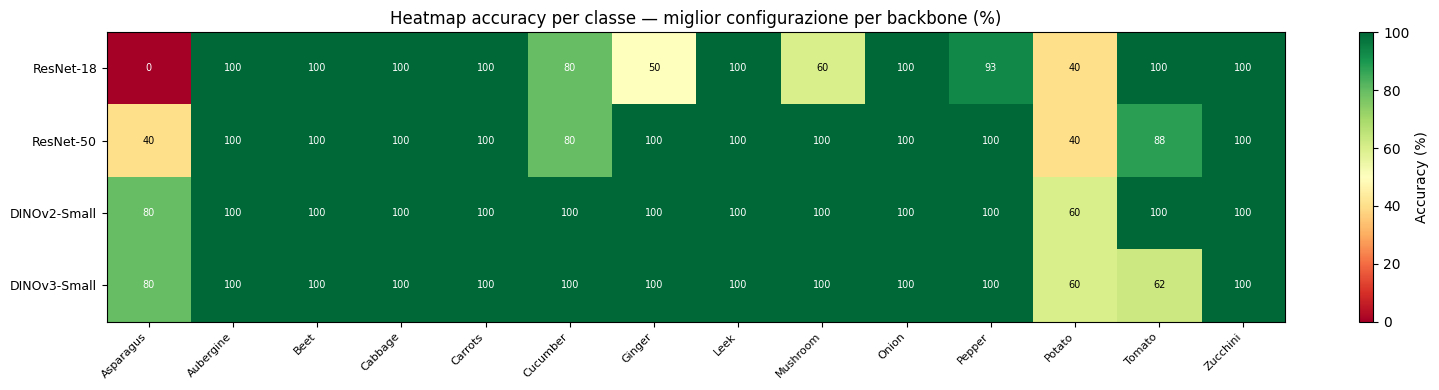

In [ ]:
# Heatmap: miglior metodo per backbone (per classe)
# Per ogni backbone prendiamo la configurazione con accuracy globale massima
# e mostriamo l'accuracy per classe in una heatmap comparativa.

class_names = all_results[backbone_names[0]]["class_names"]
n_classes   = len(class_names)

# best_acc_per_class[i, c] = accuracy della miglior config del backbone i sulla classe c
best_acc_per_class = np.zeros((len(backbone_names), n_classes))

for i, bname in enumerate(backbone_names):
    true  = all_results[bname]["true"]
    preds = all_results[bname]["pred"]
    # Trova il metodo con la miglior accuracy globale per questo backbone
    best_method = max(preds, key=lambda m: np.sum(true == preds[m]))
    for c in range(n_classes):
        mask = (true == c)
        best_acc_per_class[i, c] = np.mean(preds[best_method][mask] == c) * 100 if mask.sum() > 0 else 0

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(best_acc_per_class, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)

ax.set_xticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(backbone_names)))
ax.set_yticklabels(backbone_names, fontsize=9)
ax.set_title("Heatmap accuracy per classe — miglior configurazione per backbone (%)")

for i in range(len(backbone_names)):
    for j in range(n_classes):
        val = best_acc_per_class[i, j]
        ax.text(j, i, f"{val:.0f}", ha='center', va='center',
                fontsize=7, color='black' if 20 < val < 80 else 'white')

plt.colorbar(im, ax=ax, label="Accuracy (%)")
plt.tight_layout()
plt.show()

## Conclusioni finali

Il presente progetto ha realizzato un sistema di **product recognition** basato su nearest-neighbour search applicato a embedding estratti da backbone pre-addestrati, operando senza nessun fine-tuning sul Grocery Store Dataset ridotto, composto da 14 classi di vegetali acquisiti con smartphone in contesti reali di supermercato.

### Analisi dei risultati

**Impatto del paradigma di pre-addestramento.** Il confronto più netto emerso dalla sperimentazione riguarda la differenza tra backbone addestrati in modo supervisionato su ImageNet (ResNet-18, ResNet-50) e backbone addestrati con approccio auto-supervisionato (DINOv2-Small, DINOv3-Small). I modelli DINO producono embedding significativamente più discriminativi, con accuracy nella miglior configurazione del **94.12%** (DINOv2) e **90.59%** (DINOv3), contro l'**87.06%** di ResNet-50 e l'**80.00%** di ResNet-18. Questo risultato è coerente con la letteratura: l'apprendimento auto-supervisionato basato su DINO tende a strutturare lo spazio delle feature in modo più regolare e geometricamente separabile, poiché non è vincolato a produrre una classificazione discreta ma a massimizzare la coerenza delle rappresentazioni.

**DINOv2 con *mean|cosine* rappresenta la configurazione ottimale (94.12%).** La gallery media, costituita da un unico centroide per classe, si dimostra più efficace della gallery completa con DINOv2: questo suggerisce che gli embedding prodotti da questo backbone siano sufficientemente coerenti all'interno di ogni classe da permettere al centroide di rappresentarne fedelmente la distribuzione, riducendo allo stesso tempo il rumore introdotto dai singoli prototipi.

**Gallery ALL vs. MEAN.** Contrariamente a quanto spesso osservato nei sistemi nearest-neighbour, in questa sperimentazione la rappresentazione media per classe si è dimostrata competitiva e in alcuni casi superiore alla gallery completa, soprattutto con i backbone DINO. Ciò suggerisce che gli embedding generati da tali modelli siano sufficientemente compatti da essere rappresentati efficacemente tramite un singolo centroide.

**Cosine similarity vs. Mahalanobis.** La cosine similarity è una metrica universalmente robusta e computazionalmente efficiente. La distanza di Mahalanobis con riduzione PCA può tuttavia superarla significativamente quando le feature presentano correlazioni forti tra dimensioni: il caso più evidente è ResNet-50, in cui la configurazione *all|mahalanobis* raggiunge l'**87.06%**, guadagnando oltre 7 punti percentuali rispetto alla *all|cosine* (**80.00%**). Un caso particolarmente illustrativo è la classe Ginger con ResNet-50: la cosine similarity nella gallery completa assegna il 100% delle query a una classe errata (0% di accuracy), mentre la distanza di Mahalanobis corregge completamente questo comportamento portando l'accuracy al 100%. Ciò indica che nello spazio cosine gli embedding di Ginger con ResNet-50 collidono con quelli di un'altra classe lungo una direzione geometricamente prominente, ma distinguibile una volta tenuta in conto la struttura di covarianza.

**Classi difficili.** La classe **Asparagus** è risultata particolarmente critica per i backbone ResNet, arrivando allo **0%** con ResNet-18 e non superando il **60%** nelle migliori configurazioni ResNet. I backbone DINO migliorano sensibilmente le prestazioni, raggiungendo fino al **100%** con DINOv3. Inoltre, anche la classe **Potato** è risultata critica in generale per tutti i backbone collezionando risultati mai superiori al **60%**. Questo comportamento suggerisce che le immagini di Asparagus e Potato presentino una variabilità visiva intra-classe particolarmente alta, o una somiglianza visiva con altre categorie (es. Leek) che rende difficile la separazione nello spazio degli embedding anche in assenza di fine-tuning.

### Considerazioni conclusive

Nell'ambito della presente sperimentazione, i backbone auto-supervisionati basati su Vision Transformer si sono dimostrati la soluzione più efficace per sistemi di nearest-neighbour search a basso costo computazionale, in virtù della qualità e della struttura geometrica degli embedding prodotti. Rispetto alle architetture CNN residuali addestrate in modo supervisionato, offrono un miglioramento consistente dell'accuracy globale senza richiedere alcun adattamento al dominio applicativo.